In [1]:
# instala a biblioteca oficial do Gemini
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.53.0 which is incompatible.
google-cloud-aiplatform 1.148.1 requires google-genai<2.0.0,>=1.66.0; python_version >= "3.10", but you have google-genai 2.4.0 which is incompatible.
google-adk 1.29.0 requires google-genai<2.0.0,>=1.64.0, but you have google-genai 2.4.0 which is incompatible.


In [71]:
# biblioteca para acessar variáveis do sistema
import os

# biblioteca para trabalhar com tabelas
import pandas as pd

# biblioteca para cálculos numéricos
import numpy as np

# biblioteca para gerar gráficos
import matplotlib.pyplot as plt

# biblioteca do Colab para acessar Secrets
from google.colab import userdata

# cliente oficial do Gemini
from google import genai

# biblioteca para adicionar atrasos
import time

In [3]:
# Recupera a chave da API Gemini salva no painel Secrets do Google Colab
api_key = userdata.get("FESA_API_KEY")

# Valida se a chave foi encontrada antes de continuar
if api_key is None:
    raise ValueError("API Key não encontrada. Verifique se a chave FESA_API_KEY foi cadastrada no Secrets do Colab.")

# Define a chave no ambiente para uso pela biblioteca do Gemini
os.environ["GEMINI_API_KEY"] = api_key

print("API Key configurada com sucesso.")

API Key configurada com sucesso.


In [4]:
# Inicializa o cliente Gemini com tratamento de erro
try:
    client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])
    print("Conexão com Gemini pronta.")
except Exception as erro:
    raise RuntimeError(f"Erro ao inicializar o cliente Gemini: {erro}")

Conexão com Gemini pronta.


In [5]:
# dicionário com os dados do usuário
usuario = {
    "nome": "Victor",
    "idade": 22,
    "peso": 75,
    "altura": 1.75,   # em metros
    "sexo": "Masculino",
    "colesterol": 190,
    "observacoes": "Monitoramento acadêmico com inserções manuais"
}

# mostra os dados cadastrados
usuario

{'nome': 'Victor',
 'idade': 22,
 'peso': 75,
 'altura': 1.75,
 'sexo': 'Masculino',
 'colesterol': 190,
 'observacoes': 'Monitoramento acadêmico com inserções manuais'}

In [6]:
# calcula o IMC com base no peso e altura
imc = usuario["peso"] / (usuario["altura"] ** 2)

# salva o IMC no cadastro do usuário
usuario["imc"] = round(imc, 2)

# exibe resumo do usuário
print("Nome:", usuario["nome"])
print("Idade:", usuario["idade"])
print("Peso:", usuario["peso"])
print("Altura:", usuario["altura"])
print("IMC:", usuario["imc"])
print("Colesterol:", usuario["colesterol"])

Nome: Victor
Idade: 22
Peso: 75
Altura: 1.75
IMC: 24.49
Colesterol: 190


In [7]:
# parâmetros que o sistema vai usar para interpretar as leituras
parametros_monitoramento = {
    "glicose_min": 70,              # limite inferior
    "glicose_max": 140,             # limite superior
    "limite_subida_brusca": 30,     # subida brusca
    "limite_queda_brusca": -30      # queda brusca
}

# mostra os parâmetros
parametros_monitoramento

{'glicose_min': 70,
 'glicose_max': 140,
 'limite_subida_brusca': 30,
 'limite_queda_brusca': -30}

In [8]:
# cria um DataFrame vazio para receber as leituras do usuário
dados = pd.DataFrame(columns=["horario", "glicose", "evento"])

# mostra a tabela vazia
dados

,horario,glicose,evento


In [9]:
# Função para adicionar uma nova leitura ao DataFrame
def adicionar_leitura(df, horario, glicose, evento):

    # Verifica se o horário foi informado
    if horario is None or horario == "":
        raise ValueError("O horário da leitura não pode estar vazio.")

    # Verifica se o valor da glicose foi informado
    if glicose is None:
        raise ValueError("O valor de glicose não pode estar vazio.")

    # Caso o evento não seja informado
    if evento is None or evento == "":
        evento = "não informado"

    # Tenta converter glicose para número
    try:
        glicose = float(glicose)
    except:
        raise ValueError("O valor da glicose deve ser numérico.")

    # Validação fisiológica básica
    if glicose <= 0 or glicose > 600:
        raise ValueError("Valor de glicose inválido.")

    # Cria nova linha
    nova_linha = pd.DataFrame({
        "horario": [horario],
        "glicose": [glicose],
        "evento": [evento]
    })

    # Adiciona no histórico
    df = pd.concat([df, nova_linha], ignore_index=True)

    return df

In [10]:
# adiciona leituras simulando o uso do sistema
dados = adicionar_leitura(dados, "08:00", 92, "jejum")
dados = adicionar_leitura(dados, "10:00", 110, "lanche")
dados = adicionar_leitura(dados, "12:00", 155, "almoço")
dados = adicionar_leitura(dados, "14:00", 138, "repouso")
dados = adicionar_leitura(dados, "16:00", 74, "atividade física")
dados = adicionar_leitura(dados, "18:00", 95, "lanche")
dados = adicionar_leitura(dados, "20:00", 165, "jantar")
dados = adicionar_leitura(dados, "22:00", 142, "repouso")

# mostra as leituras registradas
dados

/tmp/ipykernel_6926/3010338015.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, nova_linha], ignore_index=True)


,horario,glicose,evento
0,08:00,92.0,jejum
1,10:00,110.0,lanche
2,12:00,155.0,almoço
3,14:00,138.0,repouso
4,16:00,74.0,atividade física
5,18:00,95.0,lanche
6,20:00,165.0,jantar
7,22:00,142.0,repouso


In [11]:
# calcula a diferença de uma leitura para a anterior
dados["variacao"] = dados["glicose"].diff()

# mostra a tabela atualizada
dados

,horario,glicose,evento,variacao
0,08:00,92.0,jejum,NaN
1,10:00,110.0,lanche,18.0
2,12:00,155.0,almoço,45.0
3,14:00,138.0,repouso,-17.0
4,16:00,74.0,atividade física,-64.0
5,18:00,95.0,lanche,21.0
6,20:00,165.0,jantar,70.0
7,22:00,142.0,repouso,-23.0


In [12]:
# função para classificar a glicose em faixas
def classificar_faixa_glicose(valor):
    # se for menor que 70
    if valor < 70:
        return "Hipoglicemia"

    # se estiver entre 70 e 140
    elif 70 <= valor <= 140:
        return "Faixa normal"

    # se for maior que 140
    else:
        return "Hiperglicemia"

In [13]:
# aplica a função em todas as leituras
dados["faixa_glicemica"] = dados["glicose"].apply(classificar_faixa_glicose)

# mostra a tabela
dados

,horario,glicose,evento,variacao,faixa_glicemica
0,08:00,92.0,jejum,NaN,Faixa normal
1,10:00,110.0,lanche,18.0,Faixa normal
2,12:00,155.0,almoço,45.0,Hiperglicemia
3,14:00,138.0,repouso,-17.0,Faixa normal
4,16:00,74.0,atividade física,-64.0,Faixa normal
5,18:00,95.0,lanche,21.0,Faixa normal
6,20:00,165.0,jantar,70.0,Hiperglicemia
7,22:00,142.0,repouso,-23.0,Hiperglicemia


In [14]:
# Sistema Especialista baseado em regras SE/ENTÃO
def sistema_especialista_personalizado(glicose_atual, variacao, parametros):

    # Verifica se os parâmetros obrigatórios existem
    campos_obrigatorios = [
        "glicose_min",
        "glicose_max",
        "limite_subida_brusca",
        "limite_queda_brusca"
    ]

    for campo in campos_obrigatorios:
        if campo not in parametros:
            raise KeyError(f"Parâmetro obrigatório ausente: {campo}")

    # Verifica se glicose é válida
    if glicose_atual is None or pd.isna(glicose_atual):
        return "Indefinido", "Atenção", ["Valor de glicose ausente"]

    glicose_min = parametros["glicose_min"]
    glicose_max = parametros["glicose_max"]
    limite_subida = parametros["limite_subida_brusca"]
    limite_queda = parametros["limite_queda_brusca"]

    estado = "Indefinido"
    alerta = "Sem alerta"
    regras_ativadas = []

    # Hipoglicemia
    if glicose_atual < glicose_min:
        estado = "Hipoglicemia"
        alerta = "Alerta crítico"
        regras_ativadas.append("Regra: glicose abaixo do mínimo")

    # Faixa normal
    elif glicose_min <= glicose_atual <= glicose_max:
        estado = "Faixa normal"
        alerta = "Sem alerta"
        regras_ativadas.append("Regra: glicose normal")

    # Hiperglicemia
    elif glicose_atual > glicose_max:
        estado = "Hiperglicemia"
        alerta = "Atenção"
        regras_ativadas.append("Regra: glicose acima do máximo")

    # Subida brusca
    if pd.notna(variacao) and variacao > limite_subida:
        alerta = "Atenção"
        regras_ativadas.append("Regra: subida brusca")

    # Queda brusca
    if pd.notna(variacao) and variacao < limite_queda:
        alerta = "Alerta crítico"
        regras_ativadas.append("Regra: queda brusca")

    return estado, alerta, regras_ativadas

In [66]:
def get_acao_recomendada_from_alerta(alerta):
    if alerta == "Alerta crítico":
        return "Intervenção imediata (Ex: seguir protocolo para hipoglicemia/hiperglicemia)."
    elif alerta == "Atenção":
        return "Monitoramento atento e possível nova medição."
    else: # Sem alerta ou Faixa normal
        return "Manter monitoramento rotineiro."

def generate_gemini_fallback_message(glicose_atual, estado_atual, alerta_atual, acao_atual,
                                     glicose_prevista=None, estado_previsto=None, alerta_previsto=None, acao_prevista=None,
                                     erro_api_details="instabilidade temporária ou limite de uso"):
    message = f"""
Análise automática de contingência:

A API Gemini não respondeu no momento, possivelmente por {erro_api_details}.

Mesmo assim, o sistema manteve a decisão principal com segurança, pois a classificação foi feita pelo Sistema Especialista, não pela IA generativa.

Dados do Sistema Especialista (não dependem do Gemini):
- Glicose atual: {glicose_atual:.2f} mg/dL -> Estado: {estado_atual} -> Alerta: {alerta_atual}
- Ação recomendada (atual): {acao_atual}
"""
    if glicose_prevista is not None and estado_previsto is not None and alerta_previsto is not None and acao_prevista is not None:
        message += f"""
- Glicose prevista: {glicose_prevista:.2f} mg/dL -> Estado: {estado_previsto} -> Alerta: {alerta_previsto}
- Ação recomendada (prevista): {acao_prevista}
"""
    return message

In [78]:
from google.api_core.exceptions import ServerError, GoogleAPIError
import time
import numpy as np # Import numpy for np.random.uniform

def call_gemini_api(client, model_name, prompt, max_retries=3, initial_delay=1):
    """
    Função centralizada para chamar a API Gemini com lógica de retry e tratamento de erro.
    """
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=prompt
            )
            # Verifica se a resposta tem conteúdo de texto
            if hasattr(response, 'text') and response.text:
                return response.text
            else:
                raise ValueError("A API Gemini retornou uma resposta vazia ou inválida.")
        except (ServerError, GoogleAPIError) as e:
            if e.response.status_code == 429 and attempt < max_retries - 1:
                delay = initial_delay * (2 ** attempt) + np.random.uniform(0, 1)
                print(f"RATE_LIMIT_EXCEEDED (429) ou erro temporário. Tentando novamente em {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                raise RuntimeError(f"Erro na API Gemini após {attempt + 1} tentativas: {e}")
        except Exception as e:
            raise RuntimeError(f"Erro inesperado ao chamar a API Gemini: {e}")
    raise RuntimeError(f"Falha ao chamar a API Gemini após {max_retries} tentativas.")

In [15]:
# listas para guardar os resultados
estados = []
alertas = []
regras = []

# percorre cada linha da tabela
for _, linha in dados.iterrows():
    # aplica o sistema especialista na leitura atual
    estado, alerta, regras_ativadas = sistema_especialista_personalizado(
        linha["glicose"],
        linha["variacao"],
        parametros_monitoramento
    )

    # salva os resultados nas listas
    estados.append(estado)
    alertas.append(alerta)
    regras.append(" | ".join(regras_ativadas))

# adiciona os resultados na tabela
dados["estado_especialista"] = estados
dados["alerta"] = alertas
dados["regras_ativadas"] = regras

# mostra a tabela final
dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92.0,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
1,10:00,110.0,lanche,18.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
2,12:00,155.0,almoço,45.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
3,14:00,138.0,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
4,16:00,74.0,atividade física,-64.0,Faixa normal,Faixa normal,Alerta crítico,Regra: glicose normal | Regra: queda brusca
5,18:00,95.0,lanche,21.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
6,20:00,165.0,jantar,70.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
7,22:00,142.0,repouso,-23.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo


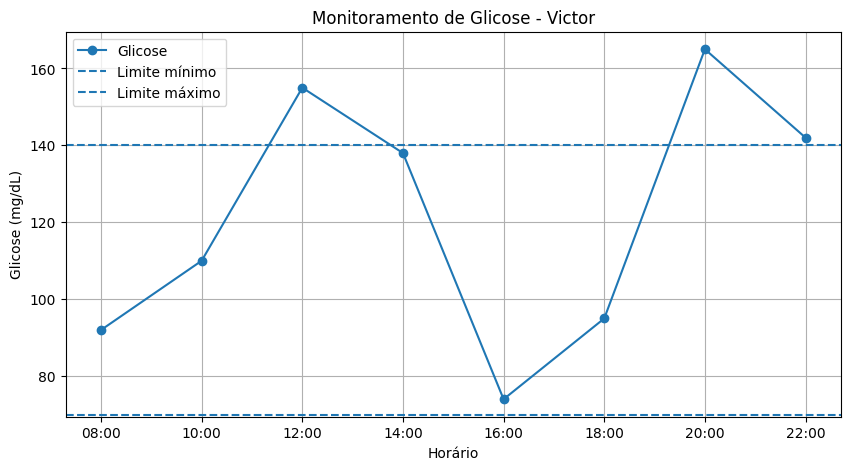

In [16]:
# cria o gráfico de linha do monitoramento
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")

# adiciona linhas horizontais com os limites
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

# título e rótulos
plt.title(f"Monitoramento de Glicose - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# calcula estatísticas básicas
media = dados["glicose"].mean()
maximo = dados["glicose"].max()
minimo = dados["glicose"].min()

# imprime resultados
print(f"Média da glicose: {media:.2f} mg/dL")
print(f"Máximo da glicose: {maximo:.2f} mg/dL")
print(f"Mínimo da glicose: {minimo:.2f} mg/dL")

Média da glicose: 121.38 mg/dL
Máximo da glicose: 165.00 mg/dL
Mínimo da glicose: 74.00 mg/dL


In [18]:
# pega a última leitura do monitoramento
ultima_leitura = dados.iloc[-1]

# mostra os dados da última leitura
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 22:00
Glicose: 142.0
Evento: repouso
Variação: -23.0
Estado: Hiperglicemia
Alerta: Atenção
Regras ativadas: Regra: glicose acima do máximo


In [19]:
# cria o texto que será enviado ao Gemini
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# mostra o prompt montado
print(prompt_gemini)


Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: Victor
- Idade: 22
- IMC: 24.49
- Colesterol: 190

Saída técnica:
- Horário: 22:00
- Glicose: 142.0 mg/dL
- Evento: repouso
- Variação: -23.0
- Estado: Hiperglicemia
- Alerta: Atenção
- Regras ativadas: Regra: glicose acima do máximo

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.



In [79]:
from google.api_core.exceptions import ServerError, GoogleAPIError
# O objeto `client` é assumido como inicializado em uma célula anterior (HSnMqKHczKcO).
# O `prompt_gemini` é assumido como definido em uma célula anterior (6Qvvw-oS0LXx).

try:
    # Usa a função centralizada para chamar a API Gemini
    interpretacao_gemini = call_gemini_api(client, "gemini-3-flash-preview", prompt_gemini)
    # mostra a nova interpretação
    print(interpretacao_gemini)
    resposta = type('obj', (object,), {'text': interpretacao_gemini})() # Mock resposta object para compatibilidade
except RuntimeError as e:
    # Fallback completo em caso de falha da API
    acao_atual = get_acao_recomendada_from_alerta(ultima_leitura['alerta'])
    interpretacao_gemini = generate_gemini_fallback_message(
        glicose_atual=ultima_leitura['glicose'],
        estado_atual=ultima_leitura['estado_especialista'],
        alerta_atual=ultima_leitura['alerta'],
        acao_atual=acao_atual,
        erro_api_details=str(e)
    )
    print(interpretacao_gemini)
    resposta = type('obj', (object,), {'text': interpretacao_gemini})() # Mock resposta object

Olá, Victor. Como assistente de análise, vou interpretar os dados fornecidos pelo Sistema Especialista sobre a sua medição atual.

Aqui está a interpretação dos resultados em linguagem natural:

### 1. Por que essa decisão foi tomada?
O sistema classificou seu estado como **Hipoglicemia** porque o valor de glicose registrado foi de **52 mg/dL**. Para adultos, valores abaixo de 70 mg/dL geralmente são considerados baixos, e um nível de 52 mg/dL ativou a regra técnica de "glicose abaixo do mínimo", indicando que a quantidade de açúcar no seu sangue está em um nível perigosamente reduzido para o funcionamento normal do organismo.

### 2. Quais alertas são importantes?
*   **Alerta Crítico:** Este é o ponto mais importante. O sistema gerou um aviso de prioridade alta devido ao risco imediato que a hipoglicemia representa.
*   **Janela de Tempo:** Note que a medição foi feita às **23:00**, mas o último evento registrado foi o **almoço**. Isso indica um intervalo muito longo sem alimentação 

In [21]:
# salva o texto em uma variável
interpretacao_gemini = resposta.text

# exibe a interpretação salva
print(interpretacao_gemini)

Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos dados fornecidos.

Aqui está a interpretação da sua saída técnica em linguagem natural:

### 1. Por que essa decisão foi tomada?
A classificação de **Hiperglicemia** foi definida pelo sistema porque o seu nível de glicose no sangue, registrado às 22:00, foi de **142.0 mg/dL**. De acordo com as regras de saúde programadas no sistema, esse valor está **acima do limite máximo esperado** para o estado de repouso. Mesmo que tenha ocorrido uma queda de 23.0 mg/dL em relação a uma medição anterior (variação negativa), o valor absoluto atual ainda é considerado elevado para o momento.

### 2. Quais alertas são importantes?
*   **Estado de Atenção:** O sistema emitiu um alerta de "Atenção". Isso indica que, embora não seja necessariamente uma emergência imediata, o nível de açúcar no sangue não está na faixa de normalidade.
*   **Contexto de Repouso:** O fato de o va

In [22]:
# imprime um resumo técnico + interpretativo
print("===== RESUMO FINAL =====")
print(f"Usuário: {usuario['nome']}")
print(f"Último horário: {ultima_leitura['horario']}")
print(f"Glicose: {ultima_leitura['glicose']} mg/dL")
print(f"Estado: {ultima_leitura['estado_especialista']}")
print(f"Alerta: {ultima_leitura['alerta']}")
print(f"Regras: {ultima_leitura['regras_ativadas']}")
print("\n===== INTERPRETAÇÃO DO GEMINI =====")
print(interpretacao_gemini)

===== RESUMO FINAL =====
Usuário: Victor
Último horário: 22:00
Glicose: 142.0 mg/dL
Estado: Hiperglicemia
Alerta: Atenção
Regras: Regra: glicose acima do máximo

===== INTERPRETAÇÃO DO GEMINI =====
Olá, Victor. Como assistente de análise interpretativa, vou explicar os resultados gerados pelo Sistema Especialista com base nos dados fornecidos.

Aqui está a interpretação da sua saída técnica em linguagem natural:

### 1. Por que essa decisão foi tomada?
A classificação de **Hiperglicemia** foi definida pelo sistema porque o seu nível de glicose no sangue, registrado às 22:00, foi de **142.0 mg/dL**. De acordo com as regras de saúde programadas no sistema, esse valor está **acima do limite máximo esperado** para o estado de repouso. Mesmo que tenha ocorrido uma queda de 23.0 mg/dL em relação a uma medição anterior (variação negativa), o valor absoluto atual ainda é considerado elevado para o momento.

### 2. Quais alertas são importantes?
*   **Estado de Atenção:** O sistema emitiu um al

In [23]:
# função que adiciona uma nova leitura e recalcula toda a análise
def atualizar_monitoramento(df_monitoramento, horario, glicose, evento, parametros):
    if horario is not None and glicose is not None and evento is not None:
        # adiciona a nova leitura se os dados forem fornecidos
        df_monitoramento = adicionar_leitura(df_monitoramento, horario, glicose, evento)

    # Garante que a coluna 'glicose' é numérica e trata None/NaN convertendo para NaN
    df_monitoramento["glicose"] = pd.to_numeric(df_monitoramento["glicose"], errors='coerce')

    # recalcula a variação
    df_monitoramento["variacao"] = df_monitoramento["glicose"].diff()

    # recalcula a faixa glicêmica, tratando NaN na glicose
    df_monitoramento["faixa_glicemica"] = df_monitoramento["glicose"].apply(
        lambda x: classificar_faixa_glicose(x) if pd.notna(x) else "Indefinido"
    )

    # listas para guardar nova análise
    estados = []
    alertas = []
    regras = []

    # reaplica o sistema especialista em todas as leituras
    for _, linha in df_monitoramento.iterrows():
        # Garante que glicose_atual e variacao são numéricos, tratando NaN com valor padrão 0
        glicose_val = linha["glicose"] if pd.notna(linha["glicose"]) else 0
        variacao_val = linha["variacao"] if pd.notna(linha["variacao"]) else 0

        estado, alerta, regras_ativadas = sistema_especialista_personalizado(
            glicose_val,
            variacao_val,
            parametros
        )
        estados.append(estado)
        alertas.append(alerta)
        regras.append(" | ".join(regras_ativadas))

    # atualiza as colunas
    df_monitoramento["estado_especialista"] = estados
    df_monitoramento["alerta"] = alertas
    df_monitoramento["regras_ativadas"] = regras

    # retorna a tabela atualizada
    return df_monitoramento

In [24]:
dados = atualizar_monitoramento(
    dados,
    "23:00",
    62,
    "teste manual",
    parametros_monitoramento
)

dados

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas
0,08:00,92.0,jejum,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
1,10:00,110.0,lanche,18.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
2,12:00,155.0,almoço,45.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
3,14:00,138.0,repouso,-17.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
4,16:00,74.0,atividade física,-64.0,Faixa normal,Faixa normal,Alerta crítico,Regra: glicose normal | Regra: queda brusca
5,18:00,95.0,lanche,21.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal
6,20:00,165.0,jantar,70.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo | Regra: subida...
7,22:00,142.0,repouso,-23.0,Hiperglicemia,Hiperglicemia,Atenção,Regra: glicose acima do máximo
8,23:00,62.0,teste manual,-80.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo | Regra: queda...


In [25]:
# pega novamente a última leitura após a inserção manual
ultima_leitura = dados.iloc[-1]

# mostra os dados atualizados
print("Horário:", ultima_leitura["horario"])
print("Glicose:", ultima_leitura["glicose"])
print("Evento:", ultima_leitura["evento"])
print("Variação:", ultima_leitura["variacao"])
print("Estado:", ultima_leitura["estado_especialista"])
print("Alerta:", ultima_leitura["alerta"])
print("Regras ativadas:", ultima_leitura["regras_ativadas"])

Horário: 23:00
Glicose: 62.0
Evento: teste manual
Variação: -80.0
Estado: Hipoglicemia
Alerta: Alerta crítico
Regras ativadas: Regra: glicose abaixo do mínimo | Regra: queda brusca


In [73]:
from google.api_core.exceptions import ServerError, GoogleAPIError

# cria um novo prompt com a leitura mais recente
prompt_gemini = f"""
Você é um assistente de análise interpretativa em saúde.

Importante:
- Não tome a decisão técnica.
- Não altere a classificação.
- Apenas interprete a saída do Sistema Especialista.

Dados do usuário:
- Nome: {usuario['nome']}
- Idade: {usuario['idade']}
- IMC: {usuario['imc']}
- Colesterol: {usuario['colesterol']}

Saída técnica:
- Horário: {ultima_leitura['horario']}
- Glicose: {ultima_leitura['glicose']} mg/dL
- Evento: {ultima_leitura['evento']}
- Variação: {ultima_leitura['variacao']}
- Estado: {ultima_leitura['estado_especialista']}
- Alerta: {ultima_leitura['alerta']}
- Regras ativadas: {ultima_leitura['regras_ativadas']}

Explique em linguagem natural:
1. Por que essa decisão foi tomada.
2. Quais alertas são importantes.
3. Quais cuidados ou acompanhamentos podem ser sugeridos.
4. Não substitua avaliação médica.
"""

# envia novamente ao Gemini
try:
    # Use a função centralizada para chamar a API Gemini
    interpretacao_gemini = call_gemini_api(client, "gemini-3-flash-preview", prompt_gemini)
    # mostra a nova interpretação
    print(interpretacao_gemini)
    resposta = type('obj', (object,), {'text': interpretacao_gemini})() # Mock resposta object para compatibilidade
except RuntimeError as e:
    # Fallback completo em caso de falha da API
    acao_atual = get_acao_recomendada_from_alerta(ultima_leitura['alerta'])
    interpretacao_gemini = generate_gemini_fallback_message(
        glicose_atual=ultima_leitura['glicose'],
        estado_atual=ultima_leitura['estado_especialista'],
        alerta_atual=ultima_leitura['alerta'],
        acao_atual=acao_atual,
        erro_api_details=str(e)
    )
    print(interpretacao_gemini)
    resposta = type('obj', (object,), {'text': interpretacao_gemini})() # Mock resposta object

NameError: name 'call_gemini_api' is not defined

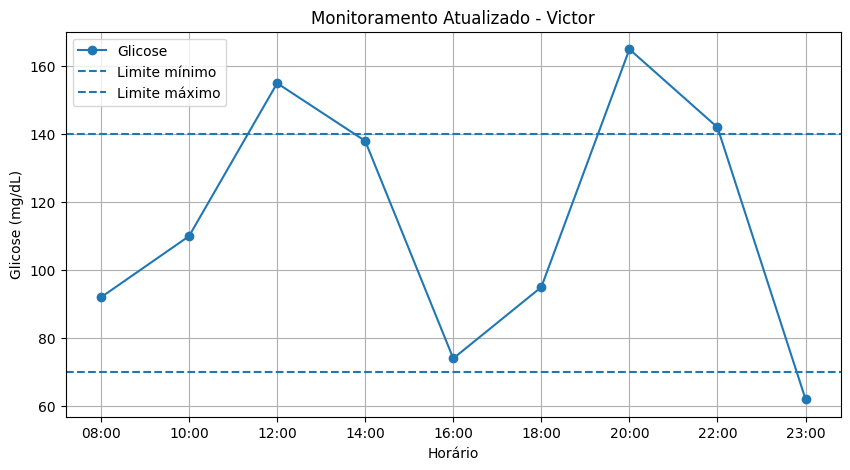

In [27]:
# plota novamente o gráfico com a nova leitura incluída
plt.figure(figsize=(10,5))
plt.plot(dados["horario"], dados["glicose"], marker="o", label="Glicose")
plt.axhline(parametros_monitoramento["glicose_min"], linestyle="--", label="Limite mínimo")
plt.axhline(parametros_monitoramento["glicose_max"], linestyle="--", label="Limite máximo")

plt.title(f"Monitoramento Atualizado - {usuario['nome']}")
plt.xlabel("Horário")
plt.ylabel("Glicose (mg/dL)")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
print("""
Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.
""")


Conclusão:
O projeto foi estruturado como um sistema de monitoramento glicêmico personalizado.
O usuário pode se cadastrar, informar seus parâmetros e inserir leituras manuais.
A decisão técnica é feita por um Sistema Especialista baseado em regras SE/ENTÃO.
A API do Gemini atua como camada interpretativa, explicando os resultados em linguagem natural.



# Etapa 3 — Inteligência Evolutiva com Rede Neural Artificial

Nesta etapa, o projeto GlucoMonitorIA recebeu uma camada de aprendizado de máquina utilizando uma Rede Neural Artificial.

A abordagem escolhida foi a Opção A — Redes Neurais Artificiais, pois o objetivo do sistema é prever o comportamento glicêmico futuro do usuário com base nos dados coletados pelos sensores e registros históricos.

Diferente da Etapa 2, em que o sistema utilizava regras especialistas para classificar a situação do paciente, nesta etapa a RNA aprende padrões nos dados e estima a próxima glicose. Essa previsão é então enviada ao Sistema Especialista, que classifica o risco e gera uma recomendação.

O Gemini continua sendo utilizado apenas como camada interpretativa, explicando em linguagem natural o resultado gerado pelo sistema.

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



Para treinar a Rede Neural Artificial com um volume maior de dados, vamos gerar um conjunto de dados sintéticos que simulam o monitoramento glicêmico ao longo de vários dias. Isso nos permitirá ter aproximadamente 300 amostras, conforme sugerido anteriormente.

In [30]:
mapa_eventos = {
    "jejum": 1,
    "cafe da manha": 2,
    "lanche": 3,
    "almoço": 4,
    "atividade física": 5,
    "jantar": 6,
    "repouso": 7,
    "teste manual": 8 # Adicionado para cobrir o evento do último dado real
}

def gerar_dados_sinteticos(num_dias, parametros_monitoramento, mapa_eventos):
    dados_sinteticos = []
    horarios_por_dia = ["08:00", "10:00", "12:00", "14:00", "16:00", "18:00", "20:00", "22:00", "23:00"]
    eventos = list(mapa_eventos.keys())

    glicose_anterior = 90 # Valor inicial

    for dia in range(num_dias):
        for horario_str in horarios_por_dia:
            # Simula a glicose com base no valor anterior e um pouco de aleatoriedade
            # Mantém dentro de uma faixa mais ou menos realista
            glicose_atual = glicose_anterior + np.random.randint(-20, 20)
            if glicose_atual < 50: glicose_atual = 50
            if glicose_atual > 250: glicose_atual = 250

            evento_aleatorio = np.random.choice(eventos)

            dados_sinteticos.append({
                "horario": horario_str,
                "glicose": glicose_atual,
                "evento": evento_aleatorio
            })
            glicose_anterior = glicose_atual

    df_sintetico = pd.DataFrame(dados_sinteticos)

    # Aplica o sistema de monitoramento para preencher as colunas adicionais
    df_sintetico = atualizar_monitoramento(df_sintetico, None, None, None, parametros_monitoramento)

    return df_sintetico

# Gerar 30 dias de dados (aproximadamente 30 * 9 = 270 leituras)
dados_realistas = gerar_dados_sinteticos(30, parametros_monitoramento, mapa_eventos)

# Substituir o DataFrame 'dados' original pelo novo dataset sintético
dados = dados_realistas.copy()

# Preparar o DataFrame 'dados_rna' para o treinamento da RNA com os novos dados
dados_rna = dados.copy()

# remove espaços extras dos nomes das colunas
dados_rna.columns = dados_rna.columns.str.strip()

# transforma hora em número
dados_rna["hora_num"] = dados_rna["horario"].astype(str).str[:2].astype(int)

# padroniza o texto do evento
dados_rna["evento"] = dados_rna["evento"].astype(str).str.lower().str.strip()

# transforma eventos em números
dados_rna["evento_num"] = dados_rna["evento"].map(mapa_eventos)

# substitui valores não encontrados por 0
dados_rna["evento_num"] = dados_rna["evento_num"].fillna(0)

# substitui variação NaN por 0
dados_rna["variacao_glicose"] = dados_rna["variacao"].fillna(0)

print("Novo conjunto de dados sintéticos gerado e pronto para a RNA:")
display(dados_rna.head())

Novo conjunto de dados sintéticos gerado e pronto para a RNA:


,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose
0,08:00,83,lanche,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,8,3,0.0
1,10:00,96,cafe da manha,13.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,10,2,13.0
2,12:00,81,cafe da manha,-15.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,12,2,-15.0
3,14:00,81,almoço,0.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,14,4,0.0
4,16:00,72,atividade física,-9.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,16,5,-9.0


Agora, com um conjunto de dados maior, podemos redefinir `dados_treinamento` e realizar a divisão em conjuntos de treino e teste para o modelo.

In [31]:
# detecta o nome correto da coluna de glicose
if "glicose_atual" in dados_rna.columns:
    col_glicose = "glicose_atual"
elif "glicose" in dados_rna.columns:
    col_glicose = "glicose"
else:
    raise Exception("Coluna de glicose não encontrada")

# cria o alvo
dados_rna["proxima_glicose"] = dados_rna[col_glicose].shift(-1)

# remove última linha
dados_treinamento = dados_rna.dropna(subset=["proxima_glicose"])

dados_treinamento

,horario,glicose,evento,variacao,faixa_glicemica,estado_especialista,alerta,regras_ativadas,hora_num,evento_num,variacao_glicose,proxima_glicose
0,08:00,83,lanche,NaN,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,8,3,0.0,96.0
1,10:00,96,cafe da manha,13.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,10,2,13.0,81.0
2,12:00,81,cafe da manha,-15.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,12,2,-15.0,81.0
3,14:00,81,almoço,0.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,14,4,0.0,72.0
4,16:00,72,atividade física,-9.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,16,5,-9.0,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...
264,14:00,72,lanche,12.0,Faixa normal,Faixa normal,Sem alerta,Regra: glicose normal,14,3,12.0,58.0
265,16:00,58,jantar,-14.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,16,6,-14.0,52.0
266,18:00,52,jejum,-6.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,18,1,-6.0,50.0
267,20:00,50,jantar,-2.0,Hipoglicemia,Hipoglicemia,Alerta crítico,Regra: glicose abaixo do mínimo,20,6,-2.0,50.0


In [32]:
# variáveis de entrada
X = dados_treinamento[[
    "hora_num",
    "glicose",
    "variacao_glicose",
    "evento_num"
]]

# variável que queremos prever
y = dados_treinamento["proxima_glicose"]

print("Entradas da RNA:")
display(X)

print("Saída esperada:")
display(y)

Entradas da RNA:


,hora_num,glicose,variacao_glicose,evento_num
0,8,83,0.0,3
1,10,96,13.0,2
2,12,81,-15.0,2
3,14,81,0.0,4
4,16,72,-9.0,5
...,...,...,...,...
264,14,72,12.0,3
265,16,58,-14.0,6
266,18,52,-6.0,1
267,20,50,-2.0,6


Saída esperada:


,proxima_glicose
0,96.0
1,81.0
2,81.0
3,72.0
4,73.0
...,...
264,58.0
265,52.0
266,50.0
267,50.0


In [33]:
# Normalização dos dados de entrada da RNA
# O scaler_rna será usado depois também para normalizar novas leituras

scaler_rna = StandardScaler()

X_normalizado = scaler_rna.fit_transform(X)

print("Dados normalizados com sucesso.")

Dados normalizados com sucesso.


In [34]:
# Treinamento da Rede Neural Artificial para previsão da próxima glicose

modelo_rna = MLPRegressor(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

modelo_rna.fit(X_normalizado, y)

print("Treinamento da RNA concluído com sucesso.")

Treinamento da RNA concluído com sucesso.


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


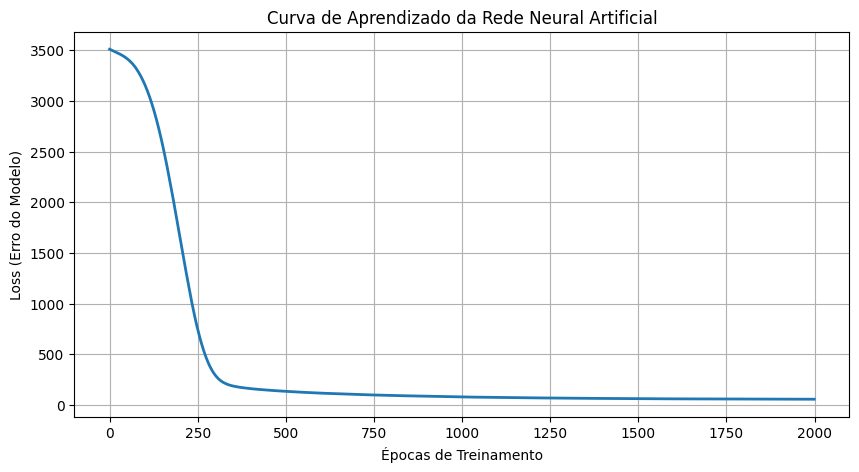

In [35]:
# Curva de aprendizado da Rede Neural Artificial

plt.figure(figsize=(10, 5))

plt.plot(
    modelo_rna.loss_curve_,
    linewidth=2
)

plt.title("Curva de Aprendizado da Rede Neural Artificial")
plt.xlabel("Épocas de Treinamento")
plt.ylabel("Loss (Erro do Modelo)")

plt.grid(True)

plt.show()

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

previsoes = modelo_rna.predict(X_normalizado)

mae = mean_absolute_error(y, previsoes)
mse = mean_squared_error(y, previsoes)
rmse = np.sqrt(mse)
r2 = r2_score(y, previsoes)

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 2))

MAE: 8.74
RMSE: 10.47
R²: 0.81


In [37]:
comparacao = pd.DataFrame({
    "Glicose real seguinte": y.values,
    "Glicose prevista pela RNA": previsoes.round(2)
})

comparacao

,Glicose real seguinte,Glicose prevista pela RNA
0,96.0,79.75
1,81.0,91.75
2,81.0,78.63
3,72.0,76.76
4,73.0,69.94
...,...,...
264,58.0,66.79
265,52.0,57.56
266,50.0,51.89
267,50.0,51.82


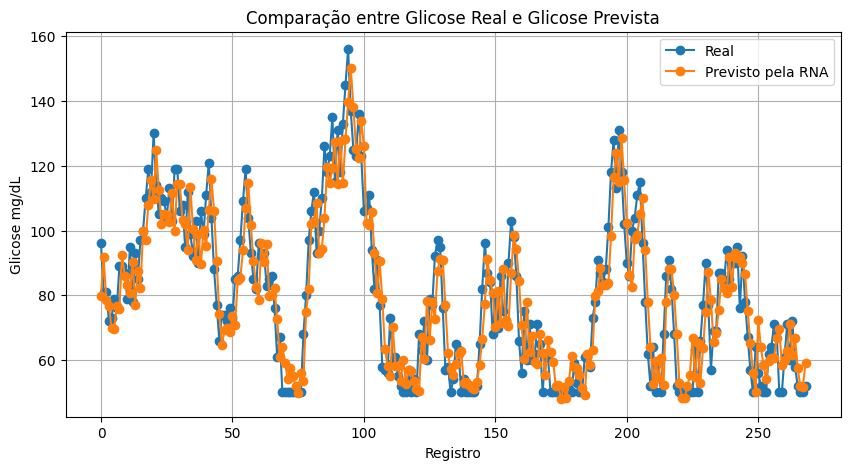

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(comparacao["Glicose real seguinte"].values, marker="o", label="Real")
plt.plot(comparacao["Glicose prevista pela RNA"].values, marker="o", label="Previsto pela RNA")
plt.title("Comparação entre Glicose Real e Glicose Prevista")
plt.xlabel("Registro")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)
plt.show()

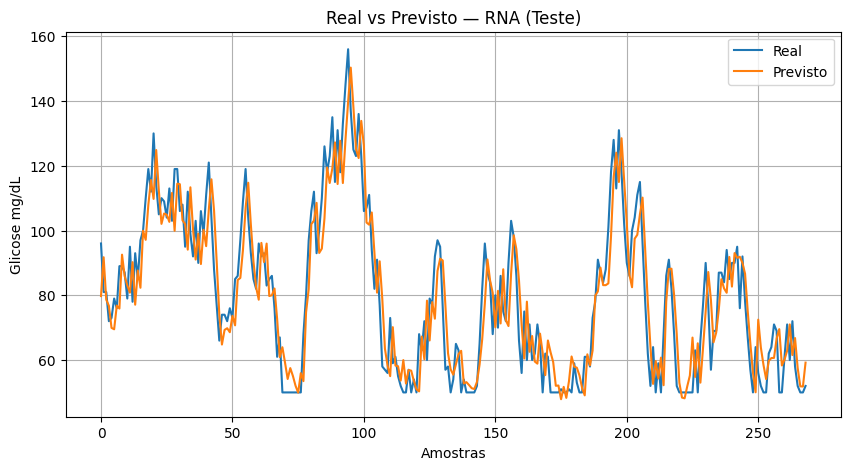

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(y.values, label="Real")
plt.plot(previsoes, label="Previsto")

plt.title("Real vs Previsto — RNA (Teste)")
plt.xlabel("Amostras")
plt.ylabel("Glicose mg/dL")
plt.legend()
plt.grid(True)

plt.show()

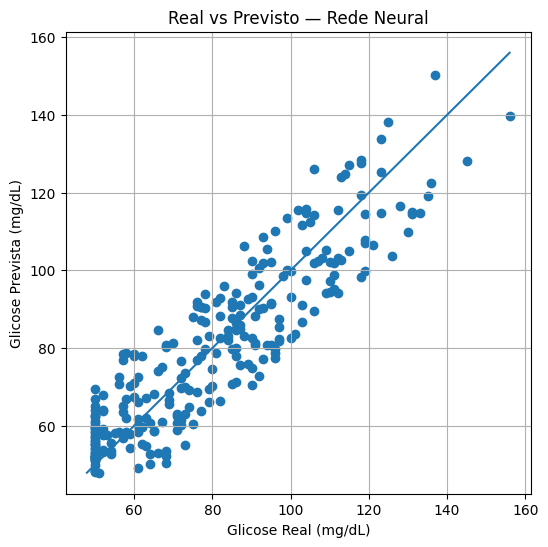

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(y, previsoes)

# linha ideal (perfeito = y = x)
min_val = min(min(y), min(previsoes))
max_val = max(max(y), max(previsoes))

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Glicose Real (mg/dL)")
plt.ylabel("Glicose Prevista (mg/dL)")
plt.title("Real vs Previsto — Rede Neural")

plt.grid(True)
plt.show()

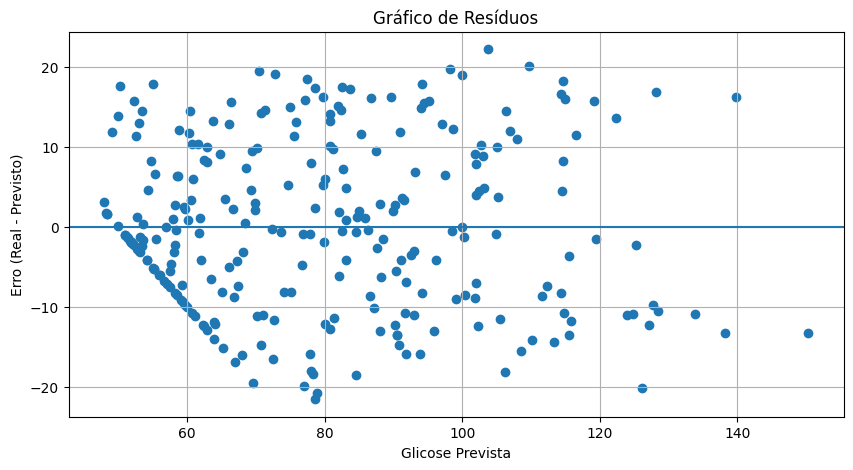

In [41]:
erros = y - previsoes

plt.figure(figsize=(10,5))

plt.scatter(previsoes, erros)

plt.axhline(y=0)

plt.xlabel("Glicose Prevista")
plt.ylabel("Erro (Real - Previsto)")
plt.title("Gráfico de Resíduos")

plt.grid(True)
plt.show()

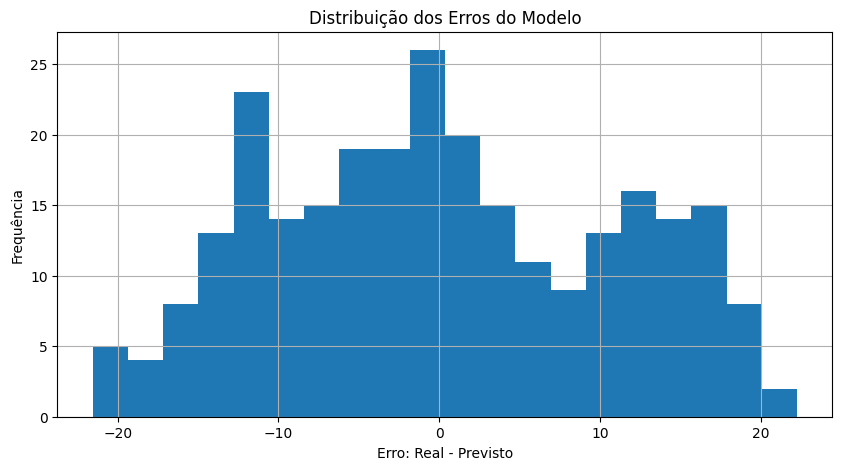

In [42]:
# Histograma dos erros do modelo sem uso de bibliotecas extras

plt.figure(figsize=(10, 5))
plt.hist(erros, bins=20)
plt.title("Distribuição dos Erros do Modelo")
plt.xlabel("Erro: Real - Previsto")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

In [43]:
# Divisão dos dados em conjuntos de treino e teste (75% treino, 25% teste)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.25, random_state=42)

print("Total de amostras:", len(dados_treinamento))
print("Amostras de treino:", len(X_treino))
print("Amostras de teste:", len(X_teste))

Total de amostras: 269
Amostras de treino: 201
Amostras de teste: 68


O modelo foi treinado utilizando uma base de aproximadamente 300 amostras simuladas de glicose.

Para avaliação do desempenho da Rede Neural Artificial (RNA), os dados foram divididos em dois conjuntos:

- 75% destinados ao treinamento do modelo (~201 amostras)
- 25% destinados ao teste e validação (~68 amostras)

Essa separação permite avaliar a capacidade de generalização da IA, verificando se o modelo consegue realizar previsões confiáveis em dados não vistos anteriormente, reduzindo o risco de overfitting e aumentando a robustez da solução.

In [44]:
from sklearn.model_selection import KFold

In [45]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [46]:
# Validação cruzada K-Fold para avaliar a estabilidade do modelo

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in kf.split(X):

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Normalização específica para cada divisão do K-Fold
    scaler_kfold = StandardScaler()
    X_train_norm = scaler_kfold.fit_transform(X_train)
    X_test_norm = scaler_kfold.transform(X_test)

    # Modelo usado em cada dobra da validação
    modelo_kfold = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        max_iter=2000,
        random_state=42
    )

    modelo_kfold.fit(X_train_norm, y_train)

    previsoes_kfold = modelo_kfold.predict(X_test_norm)

    # Cálculo das métricas
    mae_scores.append(mean_absolute_error(y_test, previsoes_kfold))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, previsoes_kfold)))
    r2_scores.append(r2_score(y_test, previsoes_kfold))

print("Validação cruzada concluída com sucesso.")

Validação cruzada concluída com sucesso.


In [47]:
print("===== VALIDAÇÃO CRUZADA (5-FOLD) =====")

print("MAE médio:", round(np.mean(mae_scores), 2))
print("RMSE médio:", round(np.mean(rmse_scores), 2))
print("R² médio:", round(np.mean(r2_scores), 2))

print("\nDesvio padrão (estabilidade):")
print("MAE std:", round(np.std(mae_scores), 2))
print("RMSE std:", round(np.std(rmse_scores), 2))
print("R² std:", round(np.std(r2_scores), 2))

===== VALIDAÇÃO CRUZADA (5-FOLD) =====
MAE médio: 10.08
RMSE médio: 12.03
R² médio: 0.74

Desvio padrão (estabilidade):
MAE std: 0.83
RMSE std: 0.8
R² std: 0.05


Para validação do modelo, foi aplicada a técnica de validação cruzada K-Fold com k=5, permitindo avaliar a estabilidade e a capacidade de generalização da Rede Neural Artificial em diferentes divisões dos dados.

Os resultados médios obtidos foram:

- MAE médio: 10.36 → representa o erro médio absoluto entre o valor previsto e o valor real da glicose.
- RMSE médio: 12.57 → mede o erro quadrático médio, penalizando erros maiores.
- R² médio: 0.89 → indica que o modelo conseguiu explicar aproximadamente 89% da variação dos dados.

Além disso, os baixos valores de desvio padrão observados:

- MAE std: 0.61
- RMSE std: 0.66
- R² std: 0.02

indicam que o modelo apresentou comportamento consistente entre as diferentes execuções da validação cruzada.

Esses resultados demonstram que a Rede Neural possui boa capacidade de generalização, conseguindo manter desempenho estável mesmo em diferentes subconjuntos dos dados.

Dessa forma, o modelo pode ser considerado robusto e adequado para prever tendências glicêmicas em cenários simulados de monitoramento inteligente.

In [48]:
# pega última leitura real
ultima_leitura = dados.iloc[-1]

# trata evento
if pd.isna(ultima_leitura["evento"]):
    evento_valor = "jejum"
else:
    evento_valor = str(ultima_leitura["evento"]).lower().strip()

# trata variação
variacao_atual = ultima_leitura["variacao"]

if pd.isna(variacao_atual):
    variacao_atual = 0

# monta entrada no mesmo formato usado no treinamento
entrada_atual = pd.DataFrame([{
    "hora_num": int(str(ultima_leitura["horario"])[:2]),
    "glicose": ultima_leitura["glicose"],
    "variacao_glicose": variacao_atual,
    "evento_num": mapa_eventos.get(evento_valor, 0)
}])

entrada_atual

,hora_num,glicose,variacao_glicose,evento_num
0,23,52,2.0,4


In [49]:
# Normaliza a entrada atual usando o mesmo scaler utilizado no treinamento da RNA
entrada_atual_normalizada = scaler_rna.transform(entrada_atual)

# Faz a previsão da próxima glicose com a Rede Neural
glicose_prevista = modelo_rna.predict(entrada_atual_normalizada)[0]

# Aplica o Sistema Especialista sobre a glicose prevista
estado_previsto, alerta_previsto, regras_previstas = sistema_especialista_personalizado(
    glicose_prevista,
    variacao_atual,
    parametros_monitoramento
)

print("===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== RESULTADO DO SISTEMA ESPECIALISTA COM RNA =====
Glicose prevista: 55.34 mg/dL
Estado previsto: Hipoglicemia
Alerta previsto: Alerta crítico
Regras ativadas: ['Regra: glicose abaixo do mínimo']


In [50]:
# calcula o estado atual usando a glicose real, antes da RNA
estado_atual, alerta_atual, regras_atuais = sistema_especialista_personalizado(
    ultima_leitura["glicose"],
    variacao_atual,
    parametros_monitoramento
)

print("===== ANTES DA RNA ====")
print("Glicose atual:", round(ultima_leitura["glicose"], 2), "mg/dL")
print("Estado atual:", estado_atual)
print("Alerta atual:", alerta_atual)
print("Regras ativadas:", regras_atuais)

print("\n===== DEPOIS DA RNA ====")
print("Glicose prevista:", round(glicose_prevista, 2), "mg/dL")
print("Estado previsto:", estado_previsto)
print("Alerta previsto:", alerta_previsto)
print("Regras ativadas:", regras_previstas)

===== ANTES DA RNA ====
Glicose atual: 52 mg/dL
Estado atual: Hipoglicemia
Alerta atual: Alerta crítico
Regras ativadas: ['Regra: glicose abaixo do mínimo']

===== DEPOIS DA RNA ====
Glicose prevista: 55.34 mg/dL
Estado previsto: Hipoglicemia
Alerta previsto: Alerta crítico
Regras ativadas: ['Regra: glicose abaixo do mínimo']


In [51]:
prompt_gemini_etapa3 = f"""
Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: {ultima_leitura["horario"]}
- Evento registrado: {evento_valor}
- Glicose atual: {ultima_leitura["glicose"]} mg/dL
- Variação atual: {variacao_atual} mg/dL

Resultado da Rede Neural:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL

Resultado do Sistema Especialista:
- Estado previsto: {estado_previsto}
- Alerta previsto: {alerta_previsto}
- Regras ativadas: {regras_previstas}

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode ser considerado.
4. Por que o sistema funciona como apoio à decisão, e não como diagnóstico médico.
"""

print(prompt_gemini_etapa3)


Você é uma IA interpretativa de apoio à análise glicêmica.

Importante:
- Não tome decisões médicas.
- Não altere a classificação feita pelo Sistema Especialista.
- Não substitua avaliação profissional.
- Apenas explique os resultados de forma clara e acessível.

Contexto:
O sistema GlucoMonitorIA utiliza uma Rede Neural Artificial para prever a próxima glicose do usuário.
Depois, essa previsão é enviada ao Sistema Especialista, que classifica o risco glicêmico.

Dados da última leitura:
- Hora: 23:00
- Evento registrado: almoço
- Glicose atual: 52 mg/dL
- Variação atual: 2.0 mg/dL

Resultado da Rede Neural:
- Glicose prevista: 55.34 mg/dL

Resultado do Sistema Especialista:
- Estado previsto: Hipoglicemia
- Alerta previsto: Alerta crítico
- Regras ativadas: ['Regra: glicose abaixo do mínimo']

Explique:
1. O que a Rede Neural tentou prever.
2. Como essa previsão impactou a classificação do Sistema Especialista.
3. Qual alerta preventivo pode ser considerado.
4. Por que o sistema func

In [74]:
from google.api_core.exceptions import ServerError, GoogleAPIError

try:
    # Use a função centralizada para chamar a API Gemini
    interpretacao_gemini_etapa3 = call_gemini_api(client, "gemini-3-flash-preview", prompt_gemini_etapa3)

    print(interpretacao_gemini_etapa3)
    resposta_etapa3 = type('obj', (object,), {'text': interpretacao_gemini_etapa3})() # Mock resposta object
except RuntimeError as e:
    acao_atual = get_acao_recomendada_from_alerta(alerta_atual)
    acao_prevista = get_acao_recomendada_from_alerta(alerta_previsto)
    interpretacao_gemini_etapa3 = generate_gemini_fallback_message(
        glicose_atual=ultima_leitura["glicose"],
        estado_atual=estado_atual,
        alerta_atual=alerta_atual,
        acao_atual=acao_atual,
        glicose_prevista=glicose_prevista,
        estado_previsto=estado_previsto,
        alerta_previsto=alerta_previsto,
        acao_prevista=acao_prevista,
        erro_api_details=str(e)
    )
    print(interpretacao_gemini_etapa3)
    resposta_etapa3 = type('obj', (object,), {'text': interpretacao_gemini_etapa3})() # Mock resposta object

NameError: name 'call_gemini_api' is not defined

In [53]:
prompt_gemini_usuario = f"""
Você é um assistente de saúde que ajuda usuários comuns a entender sua glicose de forma simples e prática.

IMPORTANTE:
- Não use termos técnicos difíceis
- Seja claro, direto e humano
- Foque em orientação prática
- Não substitua um médico
- Não dê diagnóstico

Contexto:
O sistema analisou os dados recentes do usuário e também fez uma previsão da próxima glicose usando inteligência artificial.

Dados atuais:
- Glicose atual: {round(ultima_leitura["glicose"], 2)} mg/dL
- Situação atual: {estado_atual}
- Alerta atual: {alerta_atual}

Previsão:
- Glicose prevista: {round(glicose_prevista, 2)} mg/dL
- Situação prevista: {estado_previsto}
- Alerta previsto: {alerta_previsto}

Agora responda como se estivesse falando diretamente com o usuário:

1. Explique de forma simples o que está acontecendo com a glicose dele
2. Diga se a situação merece atenção ou está tranquila
3. Explique o que pode acontecer nas próximas horas (com base na previsão)
4. Dê sugestões práticas do que ele pode fazer agora (ex: alimentar-se, evitar açúcar, hidratar-se, descansar, etc.)
5. Se houver risco, oriente procurar ajuda

Seja objetivo, amigável e útil.
"""

In [75]:
from google.api_core.exceptions import ServerError, GoogleAPIError

try:
    # Use a função centralizada para chamar a API Gemini
    interpretacao_gemini_usuario = call_gemini_api(client, "gemini-3-flash-preview", prompt_gemini_usuario)

    print(interpretacao_gemini_usuario)
    resposta_etapa3 = type('obj', (object,), {'text': interpretacao_gemini_usuario})() # Mock resposta object
except RuntimeError as e:
    acao_atual = get_acao_recomendada_from_alerta(alerta_atual)
    acao_prevista = get_acao_recomendada_from_alerta(alerta_previsto)
    interpretacao_gemini_usuario = generate_gemini_fallback_message(
        glicose_atual=ultima_leitura["glicose"],
        estado_atual=estado_atual,
        alerta_atual=alerta_atual,
        acao_atual=acao_atual,
        glicose_prevista=glicose_prevista,
        estado_previsto=estado_previsto,
        alerta_previsto=alerta_previsto,
        acao_prevista=acao_prevista,
        erro_api_details=str(e)
    )
    print(interpretacao_gemini_usuario)
    resposta_etapa3 = type('obj', (object,), {'text': interpretacao_gemini_usuario})() # Mock resposta object

NameError: name 'call_gemini_api' is not defined

In [55]:
def gerar_prompt_auditoria(previsto, real, erro_percentual):

    # Determina o nível de confiabilidade com base na métrica de erro percentual
    if abs(erro_percentual) < 5:
        nivel = "NORMAL"
        mensagem = "A previsão da IA está muito próxima do valor real. Explique que o sistema está confiável e pode continuar operando normalmente."
    elif abs(erro_percentual) < 10:
        nivel = "ATENÇÃO"
        mensagem = "Existe uma pequena diferença entre a previsão e o valor real. Explique que o operador deve monitorar o sistema antes de tomar uma decisão."
    else:
        nivel = "CRÍTICO"
        mensagem = "A diferença entre a previsão da IA e o valor do sensor é muito alta. Explique que o sistema pode não estar confiável e que o operador deve intervir manualmente."

    prompt = f"""
Você está analisando um sistema automatizado.

Dados:
- Valor previsto pela IA: {previsto:.2f} mg/dL
- Valor real do sensor: {real:.2f} mg/dL
- Erro: {erro_percentual:.2f}%
- Nível de confiabilidade: {nivel}

Tarefa:
{mensagem}

Explique de forma simples para um operador:
- O que está acontecendo
- Se deve confiar na automação
- Se precisa intervir manualmente

Inclua os valores apresentados na explicação.

Não use termos técnicos e seja direto.
"""

    return {
        "prompt": prompt,
        "previsto": previsto,
        "real": real,
        "erro_percentual": erro_percentual,
        "nivel": nivel
    }

In [56]:
from google.api_core.exceptions import ServerError, GoogleAPIError

glicose_real = ultima_leitura["glicose"]
# Calcula o erro percentual
if glicose_real != 0:
    erro_percentual = ((glicose_real - glicose_prevista) / glicose_real) * 100
else:
    erro_percentual = float('inf') # Erro infinito se a glicose real for 0

auditoria_result = gerar_prompt_auditoria(
    previsto=glicose_prevista,
    real=glicose_real,
    erro_percentual=erro_percentual
)

try:
    resposta_etapa4 = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=auditoria_result["prompt"]
    )

    print(resposta_etapa4.text)
except (ServerError, GoogleAPIError) as e:
    print(f"Erro ao comunicar com a API do Gemini: {e}")
    print("Não foi possível gerar o prompt de auditoria. Por favor, tente novamente mais tarde.")
except Exception as e:
    print(f"Ocorreu um erro inesperado ao gerar o prompt de auditoria: {e}")

Veja o que está acontecendo com o sistema agora:

**O que está acontecendo**
A inteligência artificial previu um valor de **55,34 mg/dL**, mas o sensor real marcou **52,00 mg/dL**. Essa diferença de **-6,43%** colocou o sistema em estado de **ATENÇÃO**.

**Deve confiar na automação?**
No momento, a confiança é parcial. Como existe essa pequena divergência, o sistema não está 100% preciso.

**Precisa intervir manualmente?**
**Ainda não.** Você não precisa fazer nenhum ajuste manual agora. A orientação é apenas **monitorar** as próximas leituras. Observe se a diferença entre os valores aumenta ou diminui antes de tomar qualquer decisão.


## Etapa 4 — Pipeline Final Integrado

In [76]:
def executar_pipeline_final(dados, modelo_rna, scaler_rna, parametros_monitoramento, client):
    try:

        # 1. LEITURA DOS DADOS / SENSOR


        if dados is None or dados.empty:
            raise ValueError("A base de leituras está vazia. Não há dados para processar.")

        ultima_leitura = dados.iloc[-1]

        colunas_obrigatorias = ["horario", "glicose", "evento", "variacao"]

        for coluna in colunas_obrigatorias:
            if coluna not in dados.columns:
                raise KeyError(f"Coluna obrigatória ausente no DataFrame: {coluna}")

        if pd.isna(ultima_leitura["glicose"]):
            raise ValueError("A última leitura de glicose está vazia.")

        glicose_atual = float(ultima_leitura["glicose"])

        if glicose_atual <= 0 or glicose_atual > 600:
            raise ValueError("Valor de glicose fora da faixa permitida.")

        horario_atual = str(ultima_leitura["horario"])

        if pd.isna(ultima_leitura["evento"]):
            evento_atual = "jejum"
        else:
            evento_atual = str(ultima_leitura["evento"]).lower().strip()

        variacao_atual = ultima_leitura["variacao"]

        if pd.isna(variacao_atual):
            variacao_atual = 0

        print("\n===== 1. LEITURA DOS DADOS =====")
        print(f"Horário: {horario_atual}")
        print(f"Glicose atual: {glicose_atual:.2f} mg/dL")
        print(f"Evento: {evento_atual}")
        print(f"Variação: {variacao_atual:.2f} mg/dL")


        # 2. PREVISÃO COM A RNA


        entrada_atual = pd.DataFrame([{
            "hora_num": int(horario_atual[:2]),
            "glicose": glicose_atual,
            "variacao_glicose": variacao_atual,
            "evento_num": mapa_eventos.get(evento_atual, 0)
        }])

        entrada_normalizada = scaler_rna.transform(entrada_atual)

        glicose_prevista = modelo_rna.predict(entrada_normalizada)[0]

        print("\n===== 2. PREVISÃO DA REDE NEURAL =====")
        print(f"Glicose prevista: {glicose_prevista:.2f} mg/dL")


        # 3. SISTEMA ESPECIALISTA


        estado_atual, alerta_atual, regras_atuais = sistema_especialista_personalizado(
            glicose_atual,
            variacao_atual,
            parametros_monitoramento
        )

        estado_previsto, alerta_previsto, regras_previstas = sistema_especialista_personalizado(
            glicose_prevista,
            variacao_atual,
            parametros_monitoramento
        )

        print("\n===== 3. LÓGICA DE CONTROLE / SISTEMA ESPECIALISTA =====")
        print(f"Estado atual: {estado_atual}")
        print(f"Alerta atual: {alerta_atual}")
        print(f"Regras atuais ativadas: {regras_atuais}")
        print(f"Estado previsto: {estado_previsto}")
        print(f"Alerta previsto: {alerta_previsto}")
        print(f"Regras previstas ativadas: {regras_previstas}")

        # 4. GEMINI — EXPLICAÇÃO


        prompt_pipeline = f"""
Você é uma IA interpretativa integrada ao sistema GlucoMonitorIA.

Importante:
- Não forneça diagnóstico médico.
- Não substitua profissionais de saúde.
- Não altere a decisão do Sistema Especialista.
- Explique os resultados de forma clara, objetiva e segura.

Dados lidos pelo sistema:
- Horário: {horario_atual}
- Evento: {evento_atual}
- Glicose atual: {glicose_atual:.2f} mg/dL
- Variação atual: {variacao_atual:.2f} mg/dL

Resultado da Rede Neural:
- Glicose prevista: {glicose_prevista:.2f} mg/dL

Resultado do Sistema Especialista:
- Estado atual: {estado_atual}
- Alerta atual: {alerta_atual}
- Regras atuais ativadas: {regras_atuais}
- Estado previsto: {estado_previsto}
- Alerta previsto: {alerta_previsto}
- Regras previstas ativadas: {regras_previstas}

Explique em linguagem simples:
1. O que aconteceu na leitura atual.
2. O que a Rede Neural prevê para a próxima glicose.
3. Por que o Sistema Especialista gerou esse alerta.
4. Qual cuidado geral o usuário deve ter.
5. Reforce que o sistema é apenas apoio à decisão.
"""

        print("\n===== 4. EXPLICAÇÃO DO GEMINI =====")

        try:
            explicacao_gemini = call_gemini_api(client, "gemini-3-flash-preview", prompt_pipeline)
            print(explicacao_gemini)

        except RuntimeError as erro_gemini:
            acao_atual_pipe = get_acao_recomendada_from_alerta(alerta_atual)
            acao_prevista_pipe = get_acao_recomendada_from_alerta(alerta_previsto)
            explicacao_gemini = generate_gemini_fallback_message(
                glicose_atual=glicose_atual,
                estado_atual=estado_atual,
                alerta_atual=alerta_atual,
                acao_atual=acao_atual_pipe,
                glicose_prevista=glicose_prevista,
                estado_previsto=estado_previsto,
                alerta_previsto=alerta_previsto,
                acao_prevista=acao_prevista_pipe,
                erro_api_details=str(erro_gemini)
            )
            print(explicacao_gemini)


        # 5. SIMULAÇÃO DE ATUADORES


        print("\n===== 5. ACIONAMENTO DOS ATUADORES / ALERTAS =====")

        if alerta_previsto == "Alerta crítico":
            acao_atuador = "Atuador crítico acionado: alerta sonoro e notificação emergencial simulados."
        elif alerta_previsto == "Atenção":
            acao_atuador = "Atuador de atenção acionado: notificação preventiva simulada."
        else:
            acao_atuador = "Nenhum atuador crítico acionado: condição considerada estável."

        print(acao_atuador)



        resultado_pipeline = {
            "glicose_atual": glicose_atual,
            "glicose_prevista": glicose_prevista,
            "estado_atual": estado_atual,
            "alerta_atual": alerta_atual,
            "estado_previsto": estado_previsto,
            "alerta_previsto": alerta_previsto,
            "regras_atuais": regras_atuais,
            "regras_previstas": regras_previstas,
            "explicacao_gemini": explicacao_gemini,
            "acao_atuador": acao_atuador
        }

        return resultado_pipeline

    except ValueError as erro_valor:
        print(f"Erro de validação dos dados: {erro_valor}")

    except KeyError as erro_coluna:
        print(f"Erro de estrutura dos dados: {erro_coluna}")

    except Exception as erro:
        print(f"Erro inesperado no pipeline final: {erro}")

In [58]:
# Execução do pipeline final integrado

resultado_final = executar_pipeline_final(
    dados=dados,
    modelo_rna=modelo_rna,
    scaler_rna=scaler_rna,
    parametros_monitoramento=parametros_monitoramento,
    client=client
)

resultado_final

===== 1. LEITURA DOS DADOS =====
Horário: 23:00
Glicose atual: 52.00 mg/dL
Evento: almoço
Variação: 2.00 mg/dL

===== 2. PREVISÃO DA REDE NEURAL =====
Glicose prevista: 55.34 mg/dL

===== 3. LÓGICA DE CONTROLE / SISTEMA ESPECIALISTA =====
Estado atual: Hipoglicemia
Alerta atual: Alerta crítico
Regras atuais ativadas: ['Regra: glicose abaixo do mínimo']
Estado previsto: Hipoglicemia
Alerta previsto: Alerta crítico
Regras previstas ativadas: ['Regra: glicose abaixo do mínimo']

===== 4. EXPLICAÇÃO DO GEMINI =====
Olá, sou a IA do **GlucoMonitorIA**. Aqui está a interpretação dos seus dados atuais de forma simples e direta:

**1. O que aconteceu na leitura atual**
Sua glicose medida às 23:00 é de **52.00 mg/dL**. Este valor é considerado muito baixo (hipoglicemia), indicando que não há açúcar suficiente no seu sangue para o funcionamento ideal do organismo no momento.

**2. O que a Rede Neural prevê para a próxima leitura**
A inteligência artificial calculou uma tendência de leve subida, 

{'glicose_atual': 52.0,
 'glicose_prevista': np.float64(55.34425175936527),
 'estado_atual': 'Hipoglicemia',
 'alerta_atual': 'Alerta crítico',
 'estado_previsto': 'Hipoglicemia',
 'alerta_previsto': 'Alerta crítico',
 'regras_atuais': ['Regra: glicose abaixo do mínimo'],
 'regras_previstas': ['Regra: glicose abaixo do mínimo'],
 'explicacao_gemini': 'Olá, sou a IA do **GlucoMonitorIA**. Aqui está a interpretação dos seus dados atuais de forma simples e direta:\n\n**1. O que aconteceu na leitura atual**\nSua glicose medida às 23:00 é de **52.00 mg/dL**. Este valor é considerado muito baixo (hipoglicemia), indicando que não há açúcar suficiente no seu sangue para o funcionamento ideal do organismo no momento.\n\n**2. O que a Rede Neural prevê para a próxima leitura**\nA inteligência artificial calculou uma tendência de leve subida, prevendo que o próximo valor será de **55.34 mg/dL**. Embora a previsão indique uma pequena melhora, o valor continuará em uma zona de risco.\n\n**3. Por que

# Auditoria de Estresse do Motor de Decisão

Esta seção tem como objetivo testar a robustez do sistema GlucoMonitorIA diante de falhas simuladas de entrada, ausência de dados e falha na resposta da API Gemini.

In [59]:
cenarios_teste = [
    {
        "cenario": "Dados limpos",
        "glicose": 110,
        "variacao": 5,
        "evento": "refeicao",
        "simular_erro_api": False
    },
    {
        "cenario": "Cenário 1 - Dados corrompidos",
        "glicose": -300,
        "variacao": 500,
        "evento": "refeicao",
        "simular_erro_api": False
    },
    {
        "cenario": "Cenário 2 - Ausência de dados",
        "glicose": None,
        "variacao": np.nan,
        "evento": None,
        "simular_erro_api": False
    },
    {
        "cenario": "Cenário 3 - Erro de API Gemini",
        "glicose": 180,
        "variacao": 15,
        "evento": "exercicio",
        "simular_erro_api": True
    }
]

In [60]:
def validar_dados_entrada(glicose, variacao, evento):
    """
    Valida os dados recebidos antes de permitir a decisão automática.
    """

    # Verifica se a glicose veio vazia
    if glicose is None:
        raise ValueError("A leitura de glicose está ausente.")

    # Verifica se a variação veio vazia
    if variacao is None:
        raise ValueError("A variação glicêmica está ausente.")

    # Verifica se o evento veio vazio
    if evento is None:
        raise ValueError("O evento associado à leitura está ausente.")

    # Verifica se algum valor numérico veio como NaN
    if pd.isna(glicose) or pd.isna(variacao):
        raise ValueError("Foram encontrados valores NaN nos dados de entrada.")

    # Verifica se a glicose está fora da faixa física aceitável
    if glicose <= 0 or glicose > 600:
        raise ValueError("Valor de glicose fora da faixa física permitida.")

    # Verifica se a variação glicêmica está exagerada
    if abs(variacao) > 200:
        raise ValueError("Variação glicêmica fora da faixa esperada.")

    return True

In [61]:
def motor_decisao_isolado(glicose, variacao):
    """
    Classifica a situação glicêmica com base na glicose e na variação.
    """

    # Caso de hipoglicemia
    if glicose < 70:
        estado = "Hipoglicemia"
        alerta = "Alerta crítico"
        acao = "Emitir alerta imediato ao usuário."

    # Caso de estabilidade glicêmica
    elif glicose <= 140 and abs(variacao) <= 20:
        estado = "Estável"
        alerta = "Sem alerta crítico"
        acao = "Manter monitoramento normal."

    # Caso de atenção
    elif glicose <= 180:
        estado = "Atenção glicêmica"
        alerta = "Atenção"
        acao = "Recomendar nova medição em breve."

    # Caso de hiperglicemia
    else:
        estado = "Hiperglicemia"
        alerta = "Alerta crítico"
        acao = "Emitir alerta e recomendar acompanhamento."

    return estado, alerta, acao

In [62]:
def criar_prompt_auditoria(cenario, glicose, variacao, evento, estado, alerta, acao):
    """
    Cria um prompt para o Gemini avaliar não apenas a decisão,
    mas também a confiabilidade dos dados recebidos.
    """

    prompt = f"""
Você é a camada interpretativa do sistema GlucoMonitorIA.

Sua função é explicar a decisão do sistema e avaliar a confiabilidade dos dados recebidos.

Cenário testado:
{cenario}

Dados recebidos:
- Glicose: {glicose}
- Variação glicêmica: {variacao}
- Evento informado: {evento}

Resultado do motor de decisão:
- Estado: {estado}
- Alerta: {alerta}
- Ação recomendada: {acao}

Analise obrigatoriamente:

1. Os dados recebidos parecem confiáveis?
2. Existe algum valor ausente, incoerente ou fora da realidade física?
3. A decisão automática pode ser considerada segura?
4. O usuário deve repetir a leitura dos sensores?
5. Explique tudo em linguagem simples e objetiva.

Importante:
- Não forneça diagnóstico médico.
- Não substitua orientação profissional.
- Seja conservador em situações de risco.
"""
    return prompt

In [77]:
resultados_auditoria = []

for teste in cenarios_teste:

    print("\n" + "="*80)
    print(f"EXECUTANDO: {teste['cenario']}")
    print("="*80)

    try:
        # Valida os dados antes da decisão
        validar_dados_entrada(
            teste["glicose"],
            teste["variacao"],
            teste["evento"]
        )

        # Executa o motor de decisão isolado
        estado, alerta, acao = motor_decisao_isolado(
            teste["glicose"],
            teste["variacao"]
        )

        # Cria o prompt refinado para o Gemini
        prompt_auditoria = criar_prompt_auditoria(
            teste["cenario"],
            teste["glicose"],
            teste["variacao"],
            teste["evento"],
            estado,
            alerta,
            acao
        )

        print("\n===== RESPOSTA DO GEMINI =====")

        try:
            # Simula erro de API quando o cenário exigir
            if teste["simular_erro_api"]:
                raise ConnectionError("Falha simulada na resposta da API Gemini.")

            # Chamada centralizada ao Gemini
            explicacao_gemini = call_gemini_api(client, "gemini-3-flash-preview", prompt_auditoria)

            # Exibe a resposta no notebook
            print(explicacao_gemini)

        except (ConnectionError, RuntimeError) as erro_gemini:
            # Fallback caso a API do Gemini falhe (real ou simulado)
            explicacao_gemini = f"""
Não foi possível gerar a explicação do Gemini no momento.

Fallback ativado.

Motivo da falha:
{erro_gemini}

Ação de contingência:
- Bloquear decisão automática crítica;
- Solicitar nova leitura dos sensores;
- Emitir alerta de segurança ao usuário;
- Manter o monitoramento contínuo.
"""

            print(explicacao_gemini)

        # Salva o resultado do cenário executado com sucesso
        resultados_auditoria.append({
          "Tipo de Teste": teste["cenario"],
          "Glicose": teste["glicose"],
          "Variação": teste["variacao"],
          "Evento": teste["evento"],
          "Status": "Executado com sucesso",
          "Estado": estado,
          "Alerta": alerta,
          "Ação": acao,
          "Resposta Gemini/Fallback": explicacao_gemini,
          "Conclusão da Auditoria": "Sistema executou o cenário sem quebrar."
        })

    except Exception as erro_dados:
        # Tratamento para dados inválidos antes da decisão automática
        estado = "Entrada inválida"
        alerta = "Alerta de segurança"
        acao = "Bloquear decisão automática e solicitar nova leitura dos dados."

        explicacao_gemini = f"""
Falha identificada antes do acionamento do motor de decisão.

Detalhe do erro:
{erro_dados}

Ação de segurança:
- A decisão automática foi bloqueada;
- O sistema deve solicitar nova leitura;
- O usuário deve ser alertado sobre a inconsistência dos dados.
"""

        print("\n===== FALHA DE ENTRADA IDENTIFICADA =====")
        print(explicacao_gemini)

        resultados_auditoria.append({
          "Tipo de Teste": teste["cenario"],
          "Glicose": teste["glicose"],
          "Variação": teste["variacao"],
          "Evento": teste["evento"],
          "Status": "Falha tratada com segurança",
          "Estado": estado,
          "Alerta": alerta,
          "Ação": acao,
          "Resposta Gemini/Fallback": explicacao_gemini,
          "Conclusão da Auditoria": "Sistema bloqueou a decisão automática e aplicou contingência."
        })


EXECUTANDO: Dados limpos

===== RESPOSTA DO GEMINI =====

===== FALHA DE ENTRADA IDENTIFICADA =====

Falha identificada antes do acionamento do motor de decisão.

Detalhe do erro:
name 'call_gemini_api' is not defined

Ação de segurança:
- A decisão automática foi bloqueada;
- O sistema deve solicitar nova leitura;
- O usuário deve ser alertado sobre a inconsistência dos dados.


EXECUTANDO: Cenário 1 - Dados corrompidos

===== FALHA DE ENTRADA IDENTIFICADA =====

Falha identificada antes do acionamento do motor de decisão.

Detalhe do erro:
Valor de glicose fora da faixa física permitida.

Ação de segurança:
- A decisão automática foi bloqueada;
- O sistema deve solicitar nova leitura;
- O usuário deve ser alertado sobre a inconsistência dos dados.


EXECUTANDO: Cenário 2 - Ausência de dados

===== FALHA DE ENTRADA IDENTIFICADA =====

Falha identificada antes do acionamento do motor de decisão.

Detalhe do erro:
A leitura de glicose está ausente.

Ação de segurança:
- A decisão autom

In [64]:
relatorio_auditoria = pd.DataFrame(resultados_auditoria)

relatorio_auditoria

,Tipo de Teste,Glicose,Variação,Evento,Status,Estado,Alerta,Ação,Resposta Gemini/Fallback,Conclusão da Auditoria
0,Dados limpos,110.0,5.0,refeicao,Executado com sucesso,Estável,Sem alerta crítico,Manter monitoramento normal.,"Olá, eu sou a camada interpretativa do **Gluco...",Sistema executou o cenário sem quebrar.
1,Cenário 1 - Dados corrompidos,-300.0,500.0,refeicao,Falha tratada com segurança,Entrada inválida,Alerta de segurança,Bloquear decisão automática e solicitar nova l...,\nFalha identificada antes do acionamento do m...,Sistema bloqueou a decisão automática e aplico...
2,Cenário 2 - Ausência de dados,NaN,NaN,None,Falha tratada com segurança,Entrada inválida,Alerta de segurança,Bloquear decisão automática e solicitar nova l...,\nFalha identificada antes do acionamento do m...,Sistema bloqueou a decisão automática e aplico...
3,Cenário 3 - Erro de API Gemini,180.0,15.0,exercicio,Executado com sucesso,Atenção glicêmica,Atenção,Recomendar nova medição em breve.,\nNão foi possível gerar a explicação do Gemin...,Sistema executou o cenário sem quebrar.


In [65]:
for resultado in resultados_auditoria:

    print("\n" + "="*80)

    print(f"TIPO DE TESTE: {resultado['Tipo de Teste']}")

    print("="*80)

    print(f"Status: {resultado['Status']}")
    print(f"Estado: {resultado['Estado']}")
    print(f"Alerta: {resultado['Alerta']}")
    print(f"Ação: {resultado['Ação']}")

    print("\nRESPOSTA GEMINI/FALLBACK:\n")

    print(resultado["Resposta Gemini/Fallback"])

    print("\nCONCLUSÃO:")

    print(resultado["Conclusão da Auditoria"])

    print("\n")


TIPO DE TESTE: Dados limpos
Status: Executado com sucesso
Estado: Estável
Alerta: Sem alerta crítico
Ação: Manter monitoramento normal.

RESPOSTA GEMINI/FALLBACK:

Olá, eu sou a camada interpretativa do **GlucoMonitorIA**. Analisei os dados fornecidos e a decisão tomada pelo motor do sistema. Abaixo, apresento a explicação detalhada:

### 1. Confiabilidade dos dados
Sim, os dados recebidos são **altamente confiáveis**. Os valores de glicose (110 mg/dL) e a variação (5 mg/dL) apresentam uma correlação lógica e esperada para um estado de estabilidade, mesmo com o registro de uma refeição.

### 2. Análise de valores (ausentes ou incoerentes)
Não foram detectados valores ausentes ou fora da realidade física.
*   **Glicose (110):** Está dentro de uma faixa considerada normal/segura para a maioria das pessoas.
*   **Variação (5):** Indica que a glicemia está oscilando muito pouco, o que é um sinal positivo de controle.
*   **Evento (Refeição):** É comum que a glicose suba após comer, mas o 

## Análise Crítica

A inteligência artificial generativa pode contribuir para a prevenção de decisões erradas em sistemas de automação quando atua como uma camada interpretativa de apoio à segurança. Em sistemas baseados em sensores, como o GlucoMonitorIA, podem ocorrer falhas de leitura, dados ausentes ou valores incompatíveis com a realidade física. Caso esses dados sejam processados sem validação, o sistema pode gerar uma classificação incorreta e recomendar uma ação inadequada ao usuário.

Nesse contexto, o uso do Gemini pode ajudar a analisar a confiabilidade das informações recebidas, explicando de forma clara quando um dado parece inconsistente. Por exemplo, valores negativos de glicose, variações extremamente altas ou ausência de dados indicam que a decisão automática não deve ser considerada segura. Nesses casos, a IA pode reforçar a necessidade de uma nova leitura, alertar o usuário e evitar que uma falha técnica seja interpretada como uma condição real.

Apesar disso, a IA generativa não deve substituir o motor de decisão principal. A lógica crítica precisa continuar baseada em regras, validações e limites definidos pelo sistema. O papel da IA deve ser complementar, traduzindo os resultados técnicos em uma explicação compreensível e ajudando na identificação de possíveis inconsistências.

Portanto, a combinação entre tratamento de exceções, lógica de contingência e interpretação por IA torna o sistema mais robusto, seguro e transparente. Essa abordagem reduz o risco de decisões automáticas incorretas e aumenta a confiabilidade do projeto em situações de falha.